In [2]:
import os
import shutil
import random
import numpy as np
import pandas as pd

import cv2
from scipy import stats

# Metrics
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
import seaborn as sns
import matplotlib.image as mpimg

# Deep Learning
import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

2.21.0


In [3]:
base_path = r'C:\Users\HP\OneDrive\Desktop\malaria_project'

original_dataset = os.path.join(base_path, 'cell_images')
original_dataset_parasitized = os.path.join(original_dataset, 'Parasitized')
original_dataset_uninfected = os.path.join(original_dataset, 'Uninfected')

In [4]:
# Create a base dir
base_dir = os.path.join(base_path, 'healthy_and_infected')

if not os.path.isdir(base_dir):
    os.mkdir(base_dir)

In [5]:
# Make train, valid and test directories
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

if not os.path.isdir(train_dir):
    os.mkdir(train_dir)

if not os.path.isdir(valid_dir):
    os.mkdir(valid_dir)

if not os.path.isdir(test_dir):
    os.mkdir(test_dir)

In [6]:
infected_trn_dir = os.path.join(train_dir, 'inf')
infected_valid_dir = os.path.join(valid_dir, 'inf')
infected_test_dir = os.path.join(test_dir, 'inf')

if not os.path.isdir(infected_trn_dir):
    os.mkdir(infected_trn_dir)

if not os.path.isdir(infected_valid_dir):
    os.mkdir(infected_valid_dir)

if not os.path.isdir(infected_test_dir):
    os.mkdir(infected_test_dir)

In [7]:
healthy_trn_dir = os.path.join(train_dir, 'healthy')
healthy_valid_dir = os.path.join(valid_dir, 'healthy')
healthy_test_dir = os.path.join(test_dir, 'healthy')

if not os.path.isdir(healthy_trn_dir):
    os.mkdir(healthy_trn_dir)

if not os.path.isdir(healthy_valid_dir):
    os.mkdir(healthy_valid_dir)

if not os.path.isdir(healthy_test_dir):
    os.mkdir(healthy_test_dir)

In [13]:
# Copies the first 10981 infected images to the infected_train_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) if f.endswith('.png')][:10980]

for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_trn_dir, fname)
    shutil.copyfile(src, dst)

In [14]:
# Copies the 1400 infected images (10981, 12382) to the infected_valid_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) 
          if os.path.isfile(os.path.join(original_dataset_parasitized, f)) and f.endswith('.png')][10980:12380]

for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_valid_dir, fname)
    shutil.copyfile(src, dst)

In [15]:
# Copy another 1400 infected images () to the infected_test_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) 
          if os.path.isfile(os.path.join(original_dataset_parasitized, f)) and f.endswith('.png')][12380:13780]

for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_test_dir, fname)
    shutil.copyfile(src, dst)

In [16]:
# Copies the first 10981 uninfected images to the uninfected_train_dir
fnames = [f for f in os.listdir(original_dataset_uninfected) 
          if os.path.isfile(os.path.join(original_dataset_uninfected, f)) and f.endswith('.png')][:10980]

for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_trn_dir, fname)
    shutil.copyfile(src, dst)

In [17]:
# Copies the 1400 uninfected images (10981, 12382) to the uninfected
fnames = [f for f in os.listdir(original_dataset_uninfected) 
          if os.path.isfile(os.path.join(original_dataset_uninfected, f)) and f.endswith('.png')][10980:12380]

for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_valid_dir, fname)
    shutil.copyfile(src, dst)

In [18]:
# Copy another 1400 uninfected images () to the uninfected
fnames = [f for f in os.listdir(original_dataset_uninfected) 
          if os.path.isfile(os.path.join(original_dataset_uninfected, f)) and f.endswith('.png')][12380:13780]

for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_test_dir, fname)
    shutil.copyfile(src, dst)

In [20]:
print(f"{len([f for f in os.listdir(infected_trn_dir) if f.endswith('.png')])} Infected training images")
print(f"{len([f for f in os.listdir(healthy_trn_dir) if f.endswith('.png')])} Uninfected training images")

print(f"{len([f for f in os.listdir(infected_valid_dir) if f.endswith('.png')])} Infected valid images")
print(f"{len([f for f in os.listdir(healthy_valid_dir) if f.endswith('.png')])} Uninfected valid images")

print(f"{len([f for f in os.listdir(infected_test_dir) if f.endswith('.png')])} Infected testing images")
print(f"{len([f for f in os.listdir(healthy_test_dir) if f.endswith('.png')])} Uninfected testing images")

10980 Infected training images
10980 Uninfected training images
1400 Infected valid images
1400 Uninfected valid images
1399 Infected testing images
1399 Uninfected testing images


## EDA

In [8]:
# Train
infected_trn_fpaths = [os.path.join(infected_trn_dir, fpath) for fpath in os.listdir(infected_trn_dir)]
healthy_trn_fpaths = [os.path.join(healthy_trn_dir, fpath) for fpath in os.listdir(healthy_trn_dir)]

# Valid
infected_valid_fpaths = [os.path.join(infected_valid_dir, fpath) for fpath in os.listdir(infected_valid_dir)]
healthy_valid_fpaths = [os.path.join(healthy_valid_dir, fpath) for fpath in os.listdir(healthy_valid_dir)]

# Test
infected_test_fpaths = [os.path.join(infected_test_dir, fpath) for fpath in os.listdir(infected_test_dir)]
healthy_test_fpaths = [os.path.join(healthy_test_dir, fpath) for fpath in os.listdir(healthy_test_dir)]

In [22]:
def get_img_shape(idx, img, total_num_images):
    
    if idx%2000 ==0 or idx == (total_num_images-1):
        print("working on img {}".format(idx))
    return cv2.imread(img).shape

data_inp = [(idx, img, len(infected_trn_fpaths + healthy_trn_fpaths)) for idx, img in enumerate(infected_trn_fpaths + healthy_trn_fpaths)]

train_img_dims_map = list(map(get_img_shape, [input[0] for input in data_inp],
    [input[1] for input in data_inp],
    [input[2] for input in data_inp]))

working on img 0
working on img 2000
working on img 4000
working on img 6000
working on img 8000
working on img 10000
working on img 12000
working on img 14000
working on img 16000
working on img 18000
working on img 20000
working on img 21959


In [23]:
print('Min Dimensions:           {}'.format(np.min(train_img_dims_map, axis=0)))
print('Avg Dimensions:           {}'.format(np.mean(train_img_dims_map, axis=0)))
print('Median Dimensions:        {}'.format(np.median(train_img_dims_map, axis=0)))
print('Most Frequent Dimensions: {}'.format(stats.mode(train_img_dims_map, axis=0)[0]))
print('Max Dimensions:           {}'.format(np.max(train_img_dims_map, axis=0)))

Min Dimensions:           [40 46  3]
Avg Dimensions:           [132.05751366 131.56639344   3.        ]
Median Dimensions:        [130. 130.   3.]
Most Frequent Dimensions: [130 130   3]
Max Dimensions:           [346 265   3]


In [24]:
infected_trn_samples = random.sample(infected_trn_fpaths, 5)
healthy_trn_samples = random.sample(healthy_trn_fpaths, 5)

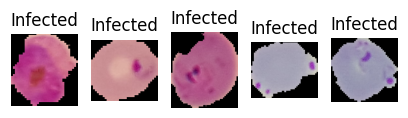

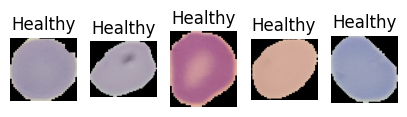

In [27]:
fig =plt.figure(figsize=(5,5))
columns=5
rows=1
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    plt.imshow(mpimg.imread(infected_trn_samples[i-1]))
    plt.axis('off')
    plt.title('Infected', fontsize=12)
plt.show()


fig =plt.figure(figsize=(5,5))
columns=5
rows=1
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    plt.imshow(mpimg.imread(healthy_trn_samples[i-1]))
    plt.axis('off')
    plt.title('Healthy', fontsize=12)
plt.show()

## Data Augmentation

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255.,
                                   horizontal_flip=0.4,
                                   vertical_flip=0.4,
                                   rotation_range=40,
                                   shear_range=0.2,
                                   width_shift_range=0.4,
                                   height_shift_range=0.4,
                                   fill_mode='nearest')
valid_datagen = ImageDataGenerator(rescale=1.0/255.)
test_datagen = ImageDataGenerator(rescale=1.0/255.)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=32,
                                                    target_size=(128,128),
                                                    class_mode='categorical',
                                                    shuffle=True,
                                                    seed=42,
                                                    color_mode='rgb')

valid_generator = valid_datagen.flow_from_directory(valid_dir,
                                                    batch_size=32,
                                                    target_size=(128, 128),
                                                    class_mode='categorical',
                                                    shuffle=True,
                                                    seed=42,
                                                    color_mode='rgb')

class_labels = train_generator.class_indices
class_names = {value:key for (key, value) in class_labels.items()}

Found 21960 images belonging to 2 classes.
Found 2800 images belonging to 2 classes.


In [29]:
class_labels, class_names

({'healthy': 0, 'inf': 1}, {0: 'healthy', 1: 'inf'})

## Transfer Learning - VGG19 CNN architecture

In [31]:
# Instantiate VGG19 model with weights from Imagenet without the calssifier at the top
base_model = VGG19(input_shape = (128,128,3),
                   include_top = False, 
                   weights = 'imagenet')
# Freeze the ConvNet to avoid weight updates
for layer in base_model.layers:
    layer.trainable=False
    
x = base_model.output
flat=Flatten()(x)

# Add a classifier -  a fully connected dense layers
class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

# Bake a model
model_01 = Model(base_model.inputs, output)
model_01.summary()

# Call backs
filepath = 'best_model.h5'
es = EarlyStopping(monitor='val_loss', verbose=1, mode='min', patience=4)
cp = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True,
                     save_weights_only=False, mode='auto', save_freq='epoch')
lrr = ReduceLROnPlateau(monitor='val_accuracy',patience=3,verbose=1,factor=0.5,min_lr=0.0001)

# Define an optimizer
sgd = SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)

# Compile the model
model_01.compile(
    loss="categorical_crossentropy",
    optimizer=sgd,
    metrics=["accuracy"]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 43,065,218 (164.28 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [33]:
# Fit the model on the training set and train for 10 epochs
history_01 = model_01.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=10,
    callbacks=[es, cp, lrr],
    validation_data=valid_generator
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5403 - loss: 0.7006
Epoch 1: val_loss improved from None to 0.65003, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 412s 8s/step - accuracy: 0.5544 - loss: 0.6901 - val_accuracy: 0.6368 - val_loss: 0.6500 - learning_rate: 1.0000e-04
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6290 - loss: 0.6427
Epoch 2: val_loss improved from 0.65003 to 0.60378, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 396s 8s/step - accuracy: 0.6288 - loss: 0.6377 - val_accuracy: 0.7107 - val_loss: 0.6038 - learning_rate: 1.0000e-04
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6749 - loss: 0.6222
Epoch 3: val_loss improved from 0.60378 to 0.57123, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 400s 8s/step - accuracy: 0.6744 - loss: 0.6147 - val_accuracy: 0.7539 - val_loss: 0.5712 - learning_rate: 1.0000e-04
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6952 - loss: 0.5940
Epoch 4: val_loss improved from 0.57123 to 0.55883, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 367s 7s/step - accuracy: 0.7038 - loss: 0.5864 - val_accuracy: 0.7436 - val_loss: 0.5588 - learning_rate: 1.0000e-04
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7303 - loss: 0.5628
Epoch 5: val_loss improved from 0.55883 to 0.53422, saving model to best_model.h5


...

50/50 ━━━━━━━━━━━━━━━━━━━━ 292s 6s/step - accuracy: 0.7194 - loss: 0.5628 - val_accuracy: 0.7768 - val_loss: 0.5171 - learning_rate: 1.0000e-04
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7549 - loss: 0.5219
Epoch 7: val_loss improved from 0.51705 to 0.49809, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 293s 6s/step - accuracy: 0.7538 - loss: 0.5246 - val_accuracy: 0.7932 - val_loss: 0.4981 - learning_rate: 1.0000e-04
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7354 - loss: 0.5214
Epoch 8: val_loss improved from 0.49809 to 0.48885, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 294s 6s/step - accuracy: 0.7431 - loss: 0.5230 - val_accuracy: 0.7950 - val_loss: 0.4889 - learning_rate: 1.0000e-04
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7508 - loss: 0.5076
Epoch 9: val_loss improved from 0.48885 to 0.47536, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 294s 6s/step - accuracy: 0.7550 - loss: 0.5094 - val_accuracy: 0.8046 - val_loss: 0.4754 - learning_rate: 1.0000e-04
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7409 - loss: 0.5324
Epoch 10: val_loss improved from 0.47536 to 0.46575, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 315s 6s/step - accuracy: 0.7519 - loss: 0.5175 - val_accuracy: 0.8064 - val_loss: 0.4658 - learning_rate: 1.0000e-04


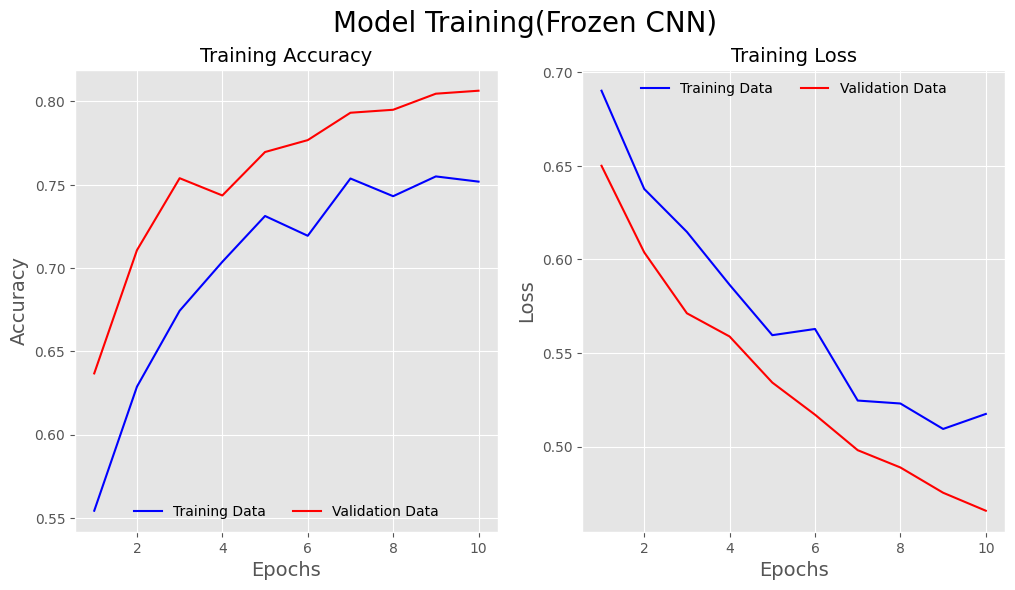

In [34]:
# Plot performance
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
fig.suptitle("Model Training(Frozen CNN)", fontsize=20)
max_epoch = len(history_01.history['accuracy'])+1
epochs_list = list(range(1, max_epoch))

ax1.plot(epochs_list, history_01.history['accuracy'], color='b', linestyle='-', label='Training Data')
ax1.plot(epochs_list, history_01.history['val_accuracy'], color='r', linestyle='-', label='Validation Data')
ax1.set_title('Training Accuracy', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=14)
ax1.legend(frameon=False, loc='lower center', ncol=2)

ax2.plot(epochs_list, history_01.history['loss'], color='b', linestyle='-', label='Training Data')
ax2.plot(epochs_list, history_01.history['val_loss'], color='r', linestyle='-', label='Validation Data')
ax2.set_title('Training Loss', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=14)
ax2.set_ylabel('Loss', fontsize=14)
ax2.legend(frameon=False, loc='upper center', ncol=2)

In [36]:
if not os.path.isdir('model_weights'):
    os.mkdir('model_weights')

model_01.save_weights('model_weights/vgg19_model_01.weights.h5')

In [11]:
# Resize test images similar to the train data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    batch_size=1,
    target_size=(128, 128),
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb'
)

Found 2798 images belonging to 2 classes.


In [38]:
# Load the saved model
model_01.load_weights('model_weights/vgg19_model_01.weights.h5')
# Evaluate the model on the hold out validation and test datasets

# Evaluate the model on batches of validation and testing data
vgg_val_eval_01 = model_01.evaluate(valid_generator)
vgg_test_eval_01 = model_01.evaluate(test_generator)

print(f"Validation loss: {vgg_val_eval_01[0]:.2f}")
print(f"Validation accuracy: {vgg_val_eval_01[1]:.2f}")
print(f"Test loss: {vgg_test_eval_01[0]:.2f}")
print(f"Test accuracy: {vgg_test_eval_01[1]:.2f}")

88/88 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.8064 - loss: 0.4658
2798/2798 ━━━━━━━━━━━━━━━━━━━━ 344s 123ms/step - accuracy: 0.8506 - loss: 0.4265
Validation loss: 0.47
Validation accuracy: 0.81
Test loss: 0.43
Test accuracy: 0.85


In [39]:
nb_samples = len(test_generator.filenames)

vgg_predictions_01 = model_01.predict(
    test_generator,
    steps=nb_samples,
    verbose=1
)

vgg_pred_labels_01 = np.argmax(vgg_predictions_01, axis=1)

2798/2798 ━━━━━━━━━━━━━━━━━━━━ 386s 138ms/step


In [40]:
# Classification Report
print(classification_report(
    test_generator.classes,
    vgg_pred_labels_01,
    target_names=['healthy', 'infected']
))

              precision    recall  f1-score   support

     healthy       0.88      0.81      0.84      1399
    infected       0.82      0.89      0.86      1399

    accuracy                           0.85      2798
   macro avg       0.85      0.85      0.85      2798
weighted avg       0.85      0.85      0.85      2798



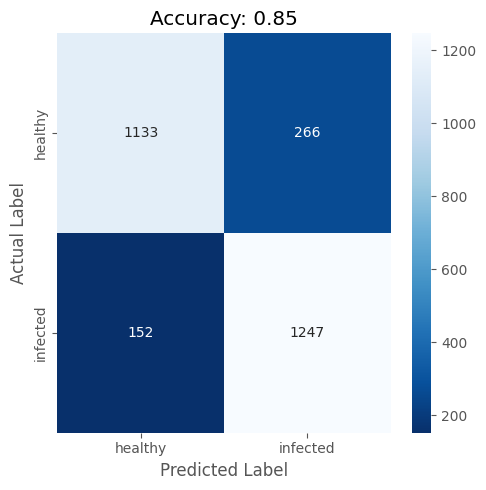

In [41]:
#Confusion Matrix
vgg_conf_mat_01 = pd.DataFrame(
    confusion_matrix(test_generator.classes, vgg_pred_labels_01),
    index=['healthy', 'infected'],
    columns=['healthy', 'infected']
)

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(vgg_conf_mat_01, annot=True, fmt="d", cmap='Blues_r')

ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")
ax.set_title(f"Accuracy: {vgg_test_eval_01[1]:.2f}")

plt.tight_layout()
plt.show()

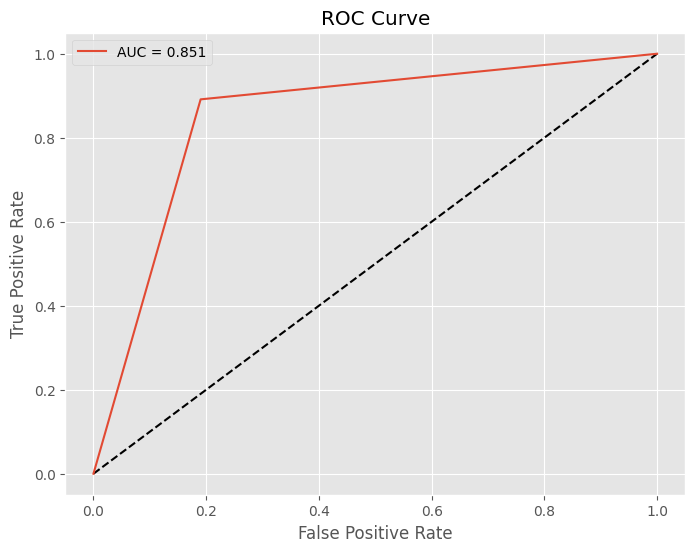

In [42]:
# AUC Curve
false_positive_rate, true_positive_rate, _ = roc_curve(
    test_generator.classes,
    vgg_pred_labels_01
)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(8,6))
ax.plot([0,1],[0,1],'k--')
ax.plot(false_positive_rate, true_positive_rate, label=f'AUC = {area_under_curve:.3f}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title("ROC Curve")
ax.legend()

plt.show()

## Incremental Unfreezing and fine-tuning

In [44]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))

x = base_model.output
flat = Flatten()(x)

class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

model_02 = Model(base_model.inputs, output)
model_02.load_weights('model_weights/vgg19_model_01.weights.h5')

set_trainable = False

for layer in base_model.layers:
    if layer.name in ['block5_conv4', 'block5_conv3']:
        set_trainable = True
    layer.trainable = set_trainable
    
print(model_02.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 47,784,834 (182.28 MB)

 Non-trainable params: 15,304,768 (58.38 MB)

None


In [45]:
sgd = SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

model_02.compile(
    optimizer=sgd,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
history_02 = model_02.fit(
    train_generator,
    steps_per_epoch=10,
    epochs=10,
    callbacks=[es, cp, lrr],
    validation_data=valid_generator
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6492 - loss: 0.6513
Epoch 1: val_loss did not improve from 0.46575
10/10 ━━━━━━━━━━━━━━━━━━━━ 237s 26s/step - accuracy: 0.6187 - loss: 0.7413 - val_accuracy: 0.5218 - val_loss: 0.6956 - learning_rate: 0.0010
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6618 - loss: 0.6200
Epoch 2: val_loss improved from 0.46575 to 0.42346, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 205s 23s/step - accuracy: 0.6906 - loss: 0.5745 - val_accuracy: 0.8207 - val_loss: 0.4235 - learning_rate: 0.0010
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7248 - loss: 0.5457
Epoch 3: val_loss improved from 0.42346 to 0.38441, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 210s 23s/step - accuracy: 0.7469 - loss: 0.5055 - val_accuracy: 0.8464 - val_loss: 0.3844 - learning_rate: 0.0010
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7753 - loss: 0.4717
Epoch 4: val_loss improved from 0.38441 to 0.33343, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 198s 22s/step - accuracy: 0.7781 - loss: 0.4798 - val_accuracy: 0.8786 - val_loss: 0.3334 - learning_rate: 0.0010
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8010 - loss: 0.4631
Epoch 5: val_loss improved from 0.33343 to 0.32212, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 190s 21s/step - accuracy: 0.7750 - loss: 0.4797 - val_accuracy: 0.8800 - val_loss: 0.3221 - learning_rate: 0.0010
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7892 - loss: 0.4357
Epoch 6: val_loss did not improve from 0.32212
10/10 ━━━━━━━━━━━━━━━━━━━━ 198s 22s/step - accuracy: 0.7906 - loss: 0.4523 - val_accuracy: 0.7961 - val_loss: 0.4089 - learning_rate: 0.0010
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8262 - loss: 0.4022
Epoch 7: val_loss improved from 0.32212 to 0.30328, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 218s 24s/step - accuracy: 0.8313 - loss: 0.3910 - val_accuracy: 0.8718 - val_loss: 0.3033 - learning_rate: 0.0010
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8151 - loss: 0.4218
Epoch 8: val_loss improved from 0.30328 to 0.28346, saving model to best_model.h5



Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
10/10 ━━━━━━━━━━━━━━━━━━━━ 213s 23s/step - accuracy: 0.8375 - loss: 0.3686 - val_accuracy: 0.8800 - val_loss: 0.2835 - learning_rate: 0.0010
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8370 - loss: 0.3568
Epoch 9: val_loss improved from 0.28346 to 0.26593, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 215s 24s/step - accuracy: 0.8281 - loss: 0.3809 - val_accuracy: 0.8932 - val_loss: 0.2659 - learning_rate: 5.0000e-04
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8563 - loss: 0.3388
Epoch 10: val_loss improved from 0.26593 to 0.26492, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 212s 23s/step - accuracy: 0.8531 - loss: 0.3531 - val_accuracy: 0.8861 - val_loss: 0.2649 - learning_rate: 5.0000e-04


In [49]:
# Load the saved model
model_02.load_weights('model_weights/vgg19_model_02.weights.h5')

# Evaluate the model on the hold out validation and test datasets
vgg_val_eval_02 = model_02.evaluate(valid_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)

print(f"Validation loss: {vgg_val_eval_02[0]:.2f}")
print(f"Validation accuracy: {vgg_val_eval_02[1]:.2f}")
print(f"Test loss: {vgg_test_eval_02[0]:.2f}")
print(f"Test accuracy: {vgg_test_eval_02[1]:.2f}")

88/88 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8861 - loss: 0.2649
2798/2798 ━━━━━━━━━━━━━━━━━━━━ 285s 102ms/step - accuracy: 0.9092 - loss: 0.2505
Validation loss: 0.26
Validation accuracy: 0.89
Test loss: 0.25
Test accuracy: 0.91


In [50]:
nb_samples = len(test_generator.filenames)

vgg_predictions_02 = model_02.predict(
    test_generator,
    steps=nb_samples,
    verbose=1
)

vgg_pred_labels_02 = np.argmax(vgg_predictions_02, axis=1)

2798/2798 ━━━━━━━━━━━━━━━━━━━━ 265s 95ms/step


In [51]:
# Classification Report
print(classification_report(
    test_generator.classes,
    vgg_pred_labels_02,
    target_names=['healthy', 'infected']
))

              precision    recall  f1-score   support

     healthy       0.88      0.94      0.91      1399
    infected       0.94      0.87      0.91      1399

    accuracy                           0.91      2798
   macro avg       0.91      0.91      0.91      2798
weighted avg       0.91      0.91      0.91      2798



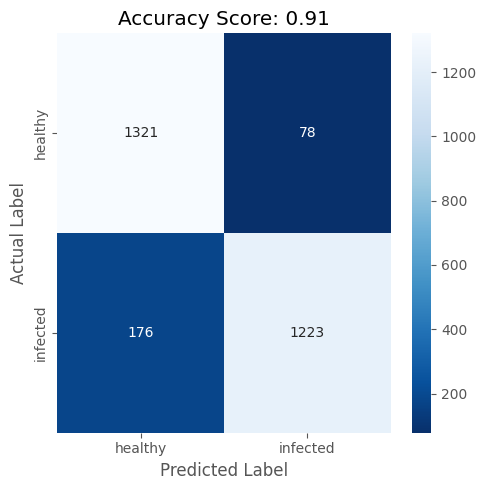

In [52]:
# Confusion Matrix
vgg_conf_mat_02 = pd.DataFrame(
    confusion_matrix(test_generator.classes, vgg_pred_labels_02),
    index=['healthy', 'infected'],
    columns=['healthy', 'infected']
)

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(vgg_conf_mat_02, annot=True, fmt="d", cmap='Blues_r')

ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")
ax.set_title(f"Accuracy Score: {vgg_test_eval_02[1]:.2f}")

plt.tight_layout()
plt.show()

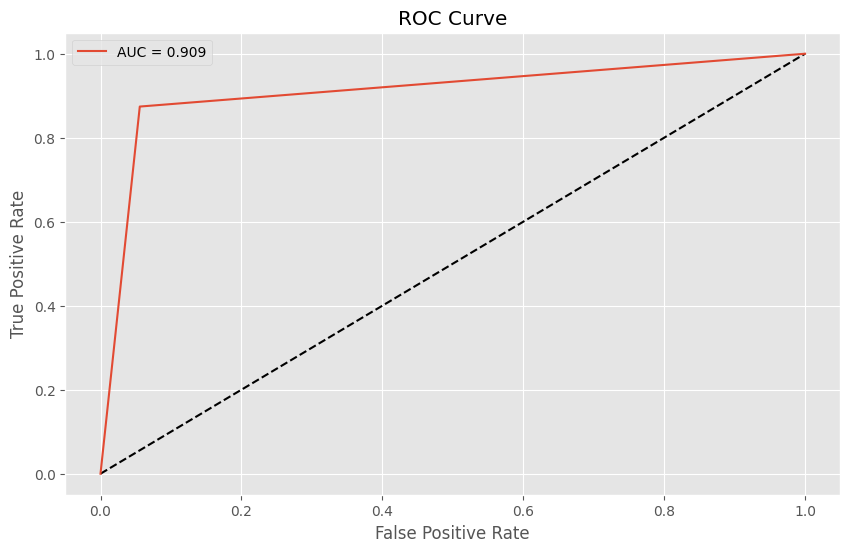

In [53]:
# AUC Curve
false_positive_rate, true_positive_rate, _ = roc_curve(
    test_generator.classes,
    vgg_pred_labels_02
)

area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(10,6))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate,
        label=f'AUC = {area_under_curve:.3f}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title("ROC Curve")
ax.legend()

plt.show()

## Unfreezing and Fine-tuning the entire network

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Callbacks
es = EarlyStopping(monitor='val_loss', mode='min', patience=4, verbose=1)

cp = ModelCheckpoint(
    'model_weights/vgg19_model_03.weights.h5',  # updated name
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lrr = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=3,
    factor=0.5,
    min_lr=0.0001,
    verbose=1
)

In [7]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))

x = base_model.output
flat = Flatten()(x)

class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

model_03 = Model(base_model.inputs, output)
model_03.load_weights('model_weights/vgg19_model_02.weights.h5')

sgd = SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)

model_03.compile(
    optimizer=sgd,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history_03 = model_03.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=35,
    callbacks=[es, cp, lrr],
    validation_data=valid_generator
)

Epoch 1/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8495 - loss: 0.3620
Epoch 1: val_loss improved from None to 0.22106, saving model to model_weights/vgg19_model_03.weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 672s 7s/step - accuracy: 0.8525 - loss: 0.3580 - val_accuracy: 0.9075 - val_loss: 0.2211 - learning_rate: 1.0000e-04
Epoch 2/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8724 - loss: 0.3107
Epoch 2: val_loss improved from 0.22106 to 0.15526, saving model to model_weights/vgg19_model_03.weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 653s 7s/step - accuracy: 0.8769 - loss: 0.3059 - val_accuracy: 0.9546 - val_loss: 0.1553 - learning_rate: 1.0000e-04
Epoch 3/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8829 - loss: 0.2928
Epoch 3: val_loss improved from 0.15526 to 0.14460, saving model to model_weights/vgg19_model_03.weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 766s 8s/step - accuracy: 0.8838 - loss: 0.2962 - val_accuracy: 0.9611 - val_loss: 0.1446 - learning_rate: 1.0000e-04
Epoch 4/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8799 - loss: 0.2942
Epoch 4: val_loss improved from 0.14460 to 0.12944, saving model to model_weights/vgg19_model_03.weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 679s 7s/step - accuracy: 0.8800 - loss: 0.2906 - val_accuracy: 0.9596 - val_loss: 0.1294 - learning_rate: 1.0000e-04
Epoch 5/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8997 - loss: 0.2657
Epoch 5: val_loss improved from 0.12944 to 0.12534, saving model to model_weights/vgg19_model_03.weights.h5


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 836s 8s/step - accuracy: 0.8989 - loss: 0.2719 - val_accuracy: 0.9639 - val_loss: 0.1167 - learning_rate: 1.0000e-04
Epoch 11/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8865 - loss: 0.2805
Epoch 11: val_loss did not improve from 0.11671
100/100 ━━━━━━━━━━━━━━━━━━━━ 776s 8s/step - accuracy: 0.8928 - loss: 0.2734 - val_accuracy: 0.9571 - val_loss: 0.1250 - learning_rate: 1.0000e-04
Epoch 12/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8972 - loss: 0.2642
Epoch 12: val_loss improved from 0.11671 to 0.11291, saving model to model_weights/vgg19_model_03.weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 609s 6s/step - accuracy: 0.8994 - loss: 0.2517 - val_accuracy: 0.9693 - val_loss: 0.1129 - learning_rate: 1.0000e-04
Epoch 13/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8936 - loss: 0.2784
Epoch 13: val_loss did not improve from 0.11291
100/100 ━━━━━━━━━━━━━━━━━━━━ 608s 6s/step - accuracy: 0.8972 - loss: 0.2697 - val_accuracy: 0.9689 - val_loss: 0.1268 - learning_rate: 1.0000e-04
Epoch 14/35
 87/100 ━━━━━━━━━━━━━━━━━━━━ 1:17 6s/step - accuracy: 0.9104 - loss: 0.2283
Epoch 14: val_loss improved from 0.11291 to 0.11198, saving model to model_weights/vgg19_model_03.weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 704s 7s/step - accuracy: 0.8987 - loss: 0.2459 - val_accuracy: 0.9639 - val_loss: 0.1120 - learning_rate: 1.0000e-04
Epoch 15/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9053 - loss: 0.2414
Epoch 15: val_loss did not improve from 0.11198
100/100 ━━━━━━━━━━━━━━━━━━━━ 923s 9s/step - accuracy: 0.9062 - loss: 0.2402 - val_accuracy: 0.9650 - val_loss: 0.1250 - learning_rate: 1.0000e-04
Epoch 16/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9026 - loss: 0.2439
Epoch 16: val_loss did not improve from 0.11198
100/100 ━━━━━━━━━━━━━━━━━━━━ 715s 7s/step - accuracy: 0.8938 - loss: 0.2601 - val_accuracy: 0.9671 - val_loss: 0.1190 - learning_rate: 1.0000e-04
Epoch 17/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9093 - loss: 0.2327
Epoch 17: val_loss did not improve from 0.11198
100/100 ━━━━━━━━━━━━━━━━━━━━ 695s 7s/step - accuracy: 0.8969 - loss: 0.2551 - val_accuracy: 0.9611 - val_loss: 0.1439 - learning_rate: 1.0000e-04
Epoch 18/35
10

100/100 ━━━━━━━━━━━━━━━━━━━━ 729s 7s/step - accuracy: 0.9013 - loss: 0.2504 - val_accuracy: 0.9661 - val_loss: 0.1067 - learning_rate: 1.0000e-04
Epoch 19/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9089 - loss: 0.2284
Epoch 19: val_loss improved from 0.10671 to 0.10507, saving model to model_weights/vgg19_model_03.weights.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 669s 7s/step - accuracy: 0.9047 - loss: 0.2400 - val_accuracy: 0.9668 - val_loss: 0.1051 - learning_rate: 1.0000e-04
Epoch 20/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9112 - loss: 0.2408
Epoch 20: val_loss did not improve from 0.10507
100/100 ━━━━━━━━━━━━━━━━━━━━ 656s 7s/step - accuracy: 0.9068 - loss: 0.2395 - val_accuracy: 0.9671 - val_loss: 0.1101 - learning_rate: 1.0000e-04
Epoch 21/35
 87/100 ━━━━━━━━━━━━━━━━━━━━ 1:16 6s/step - accuracy: 0.8959 - loss: 0.2415
Epoch 21: val_loss did not improve from 0.10507
100/100 ━━━━━━━━━━━━━━━━━━━━ 669s 7s/step - accuracy: 0.9037 - loss: 0.2387 - val_accuracy: 0.9679 - val_loss: 0.1070 - learning_rate: 1.0000e-04
Epoch 22/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8932 - loss: 0.2607
Epoch 22: val_loss did not improve from 0.10507
100/100 ━━━━━━━━━━━━━━━━━━━━ 1189s 12s/step - accuracy: 0.8953 - loss: 0.2581 - val_accuracy: 0.9671 - val_loss: 0.1064 - learning_rate: 1.0000e-04
Epoch 23/3

In [9]:
if not os.path.isdir('model_weights'):
    os.mkdir('model_weights')

model_03.save_weights('model_weights/vgg_unfrozen.weights.h5')

In [13]:
# Load the saved model
model_03.load_weights('model_weights/vgg_unfrozen.weights.h5')
# Evaluate the model on the hold out validation and test datasets
vgg_val_eval_03 = model_03.evaluate(valid_generator)
vgg_test_eval_03 = model_03.evaluate(test_generator)

print(f"Validation loss: {vgg_val_eval_03[0]:.2f}")
print(f"Validation accuracy: {vgg_val_eval_03[1]:.2f}")
print(f"Test loss: {vgg_test_eval_03[0]:.2f}")
print(f"Test accuracy: {vgg_test_eval_03[1]:.2f}")

88/88 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.9689 - loss: 0.1203
2798/2798 ━━━━━━━━━━━━━━━━━━━━ 224s 80ms/step - accuracy: 0.9514 - loss: 0.1494
Validation loss: 0.12
Validation accuracy: 0.97
Test loss: 0.15
Test accuracy: 0.95


In [14]:
nb_samples = len(test_generator.filenames)

vgg_predictions_03 = model_03.predict(
    test_generator,
    steps=nb_samples,
    verbose=1
)

vgg_pred_labels_03 = np.argmax(vgg_predictions_03, axis=1)

2798/2798 ━━━━━━━━━━━━━━━━━━━━ 216s 77ms/step


In [15]:
# Classification report
print(classification_report(
    test_generator.classes,
    vgg_pred_labels_03,
    target_names=['healthy', 'infected']
))

              precision    recall  f1-score   support

     healthy       0.95      0.95      0.95      1399
    infected       0.95      0.95      0.95      1399

    accuracy                           0.95      2798
   macro avg       0.95      0.95      0.95      2798
weighted avg       0.95      0.95      0.95      2798



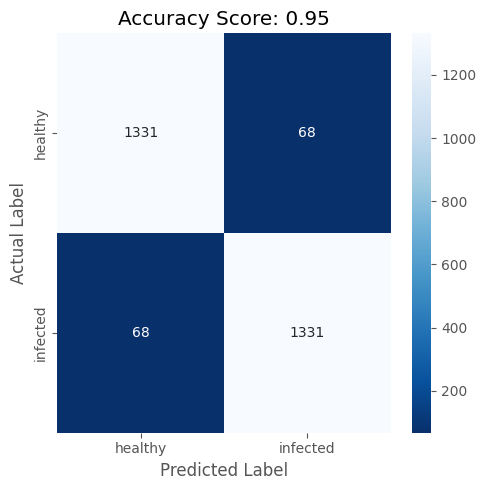

In [16]:
# Confusion Matrix
vgg_conf_mat_03 = pd.DataFrame(
    confusion_matrix(test_generator.classes, vgg_pred_labels_03),
    index=['healthy', 'infected'],
    columns=['healthy', 'infected']
)

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(vgg_conf_mat_03, annot=True, fmt="d", cmap='Blues_r')

ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")
ax.set_title(f"Accuracy Score: {vgg_test_eval_03[1]:.2f}")

plt.tight_layout()
plt.show()

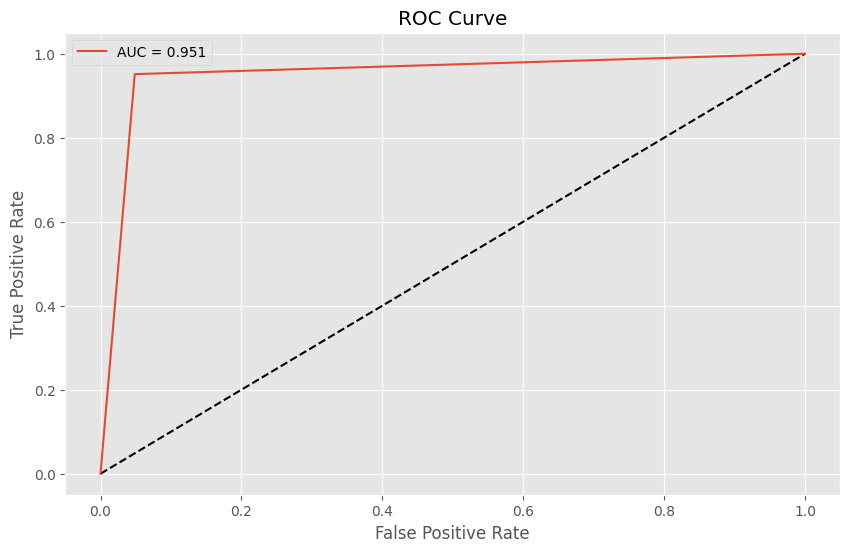

In [17]:
fpr, tpr, _ = roc_curve(test_generator.classes, vgg_pred_labels_03)
auc_score = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot([0,1],[0,1],'k--')
ax.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title("ROC Curve")
ax.legend()

plt.show()

## Prediction Results for 10 randomly selected images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


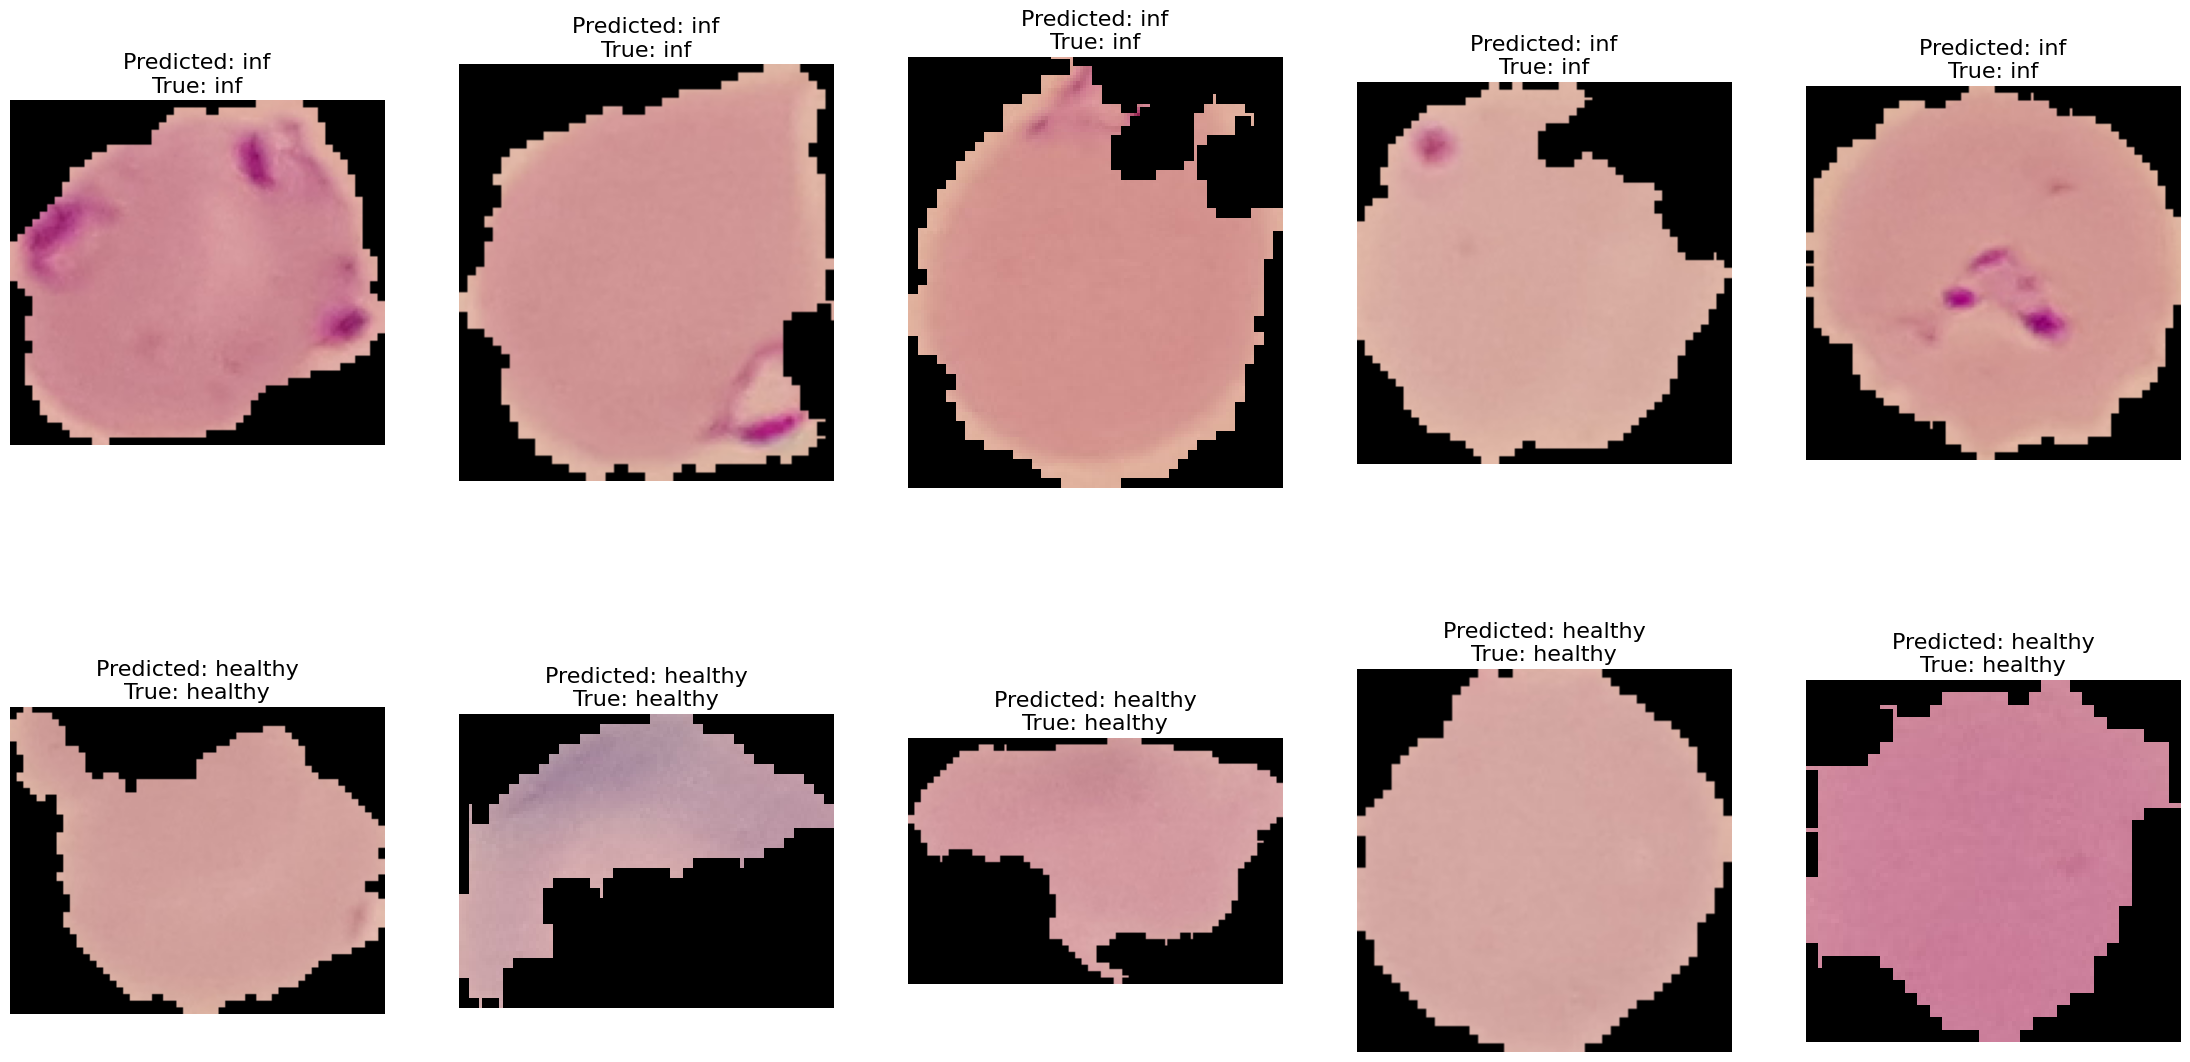

In [24]:
from tensorflow.keras.preprocessing import image 

test_images = random.sample(infected_test_fpaths, 5) + \
              random.sample(healthy_test_fpaths, 5)

true_labels = []

fig = plt.figure(figsize=(28,14))
columns, rows = 5, 2

for i in range(1, columns*rows + 1):
    fig.add_subplot(rows, columns, i)

    img_path = test_images[i-1]

    # FIX: Windows path issue
    true_label = img_path.split(os.sep)[-2]
    true_labels.append(true_label)

    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')

    img = image.load_img(img_path, target_size=(128,128))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0) / 255.0

    prediction = model_03.predict(img)
    predicted_label = np.argmax(prediction)

    plt.title(
        f"Predicted: {class_names[predicted_label]}\nTrue: {true_label}",
        fontsize=16
    )

plt.show()

In [37]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
import os

from tensorflow.keras.preprocessing import image

In [38]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([img_array])  # IMPORTANT FIX
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [39]:
# pick 6 infected test images
infected_samples = random.sample(infected_test_fpaths, 6)

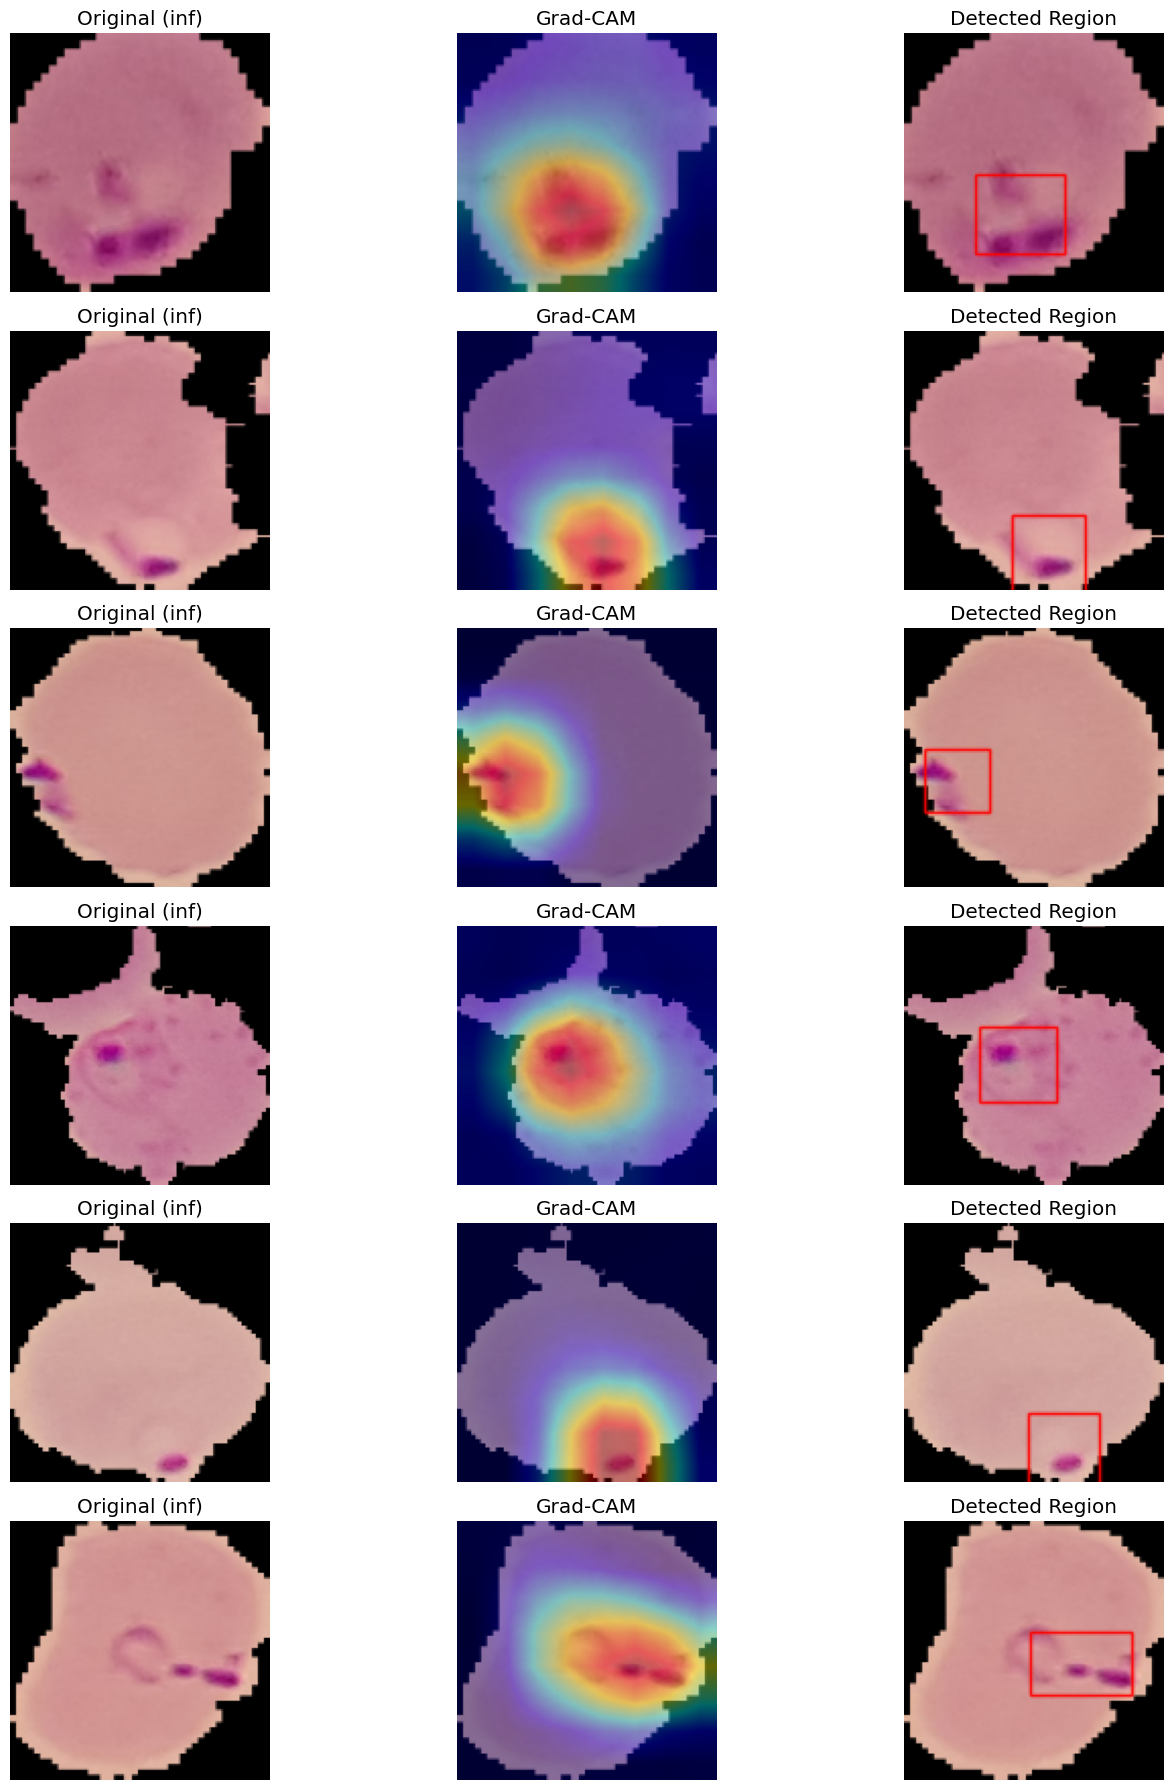

In [42]:
plt.figure(figsize=(15, 18))

for i, img_path in enumerate(infected_samples):

    # ---- Preprocess for model ----
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # ---- Generate Grad-CAM ----
    heatmap = get_gradcam_heatmap(model_03, img_array, "block5_conv4")

    # ---- Load original image ----
    original = cv2.imread(img_path)
    original = cv2.resize(original, (128, 128))
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # ---- Resize heatmap ----
    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_resized_uint8 = np.uint8(255 * heatmap_resized)

    # ---- Apply color map ----
    heatmap_colored = cv2.applyColorMap(heatmap_resized_uint8, cv2.COLORMAP_JET)

    # ---- Overlay ----
    overlay = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    # ---- Create RED BOX ----
    threshold = 0.75
    mask = heatmap_resized > threshold

    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxed = original.copy()

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(boxed, (x, y), (x+w, y+h), (0, 0, 255), 1, lineType=cv2.LINE_AA)

    boxed = cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)

    label = img_path.split(os.sep)[-2]

    # ---- Plot Original ----
    plt.subplot(6, 3, 3*i + 1)
    plt.imshow(original_rgb)
    plt.title(f"Original ({label})")
    plt.axis('off')

    # ---- Plot Grad-CAM ----
    plt.subplot(6, 3, 3*i + 2)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis('off')

    # ---- Plot Red Box ----
    plt.subplot(6, 3, 3*i + 3)
    plt.imshow(boxed)
    plt.title("Detected Region")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))

x = base_model.output
flat = Flatten()(x)

class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

model_03 = Model(base_model.inputs, output)
model_03.load_weights('model_weights/vgg19_model_02.weights.h5')

sgd = SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)

model_03.compile(
    optimizer=sgd,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Load trained model (IMPORTANT)
model_03.load_weights('model_weights/vgg_unfrozen.weights.h5')

# Convert to TFLite with quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model_03)

# Enable optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()

# Save model
with open('malaria_model_quantized.tflite', 'wb') as f:
    f.write(tflite_model)

print("Quantized model saved!")

C:\Users\HP\miniconda3\envs\malaria_cnn\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpx0jhji_r\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpx0jhji_r\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpx0jhji_r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1907075642144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907075639152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907075643376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907075643728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907075643024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907075908880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907061644224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907075912048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907075910816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907075914864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  19070759

In [15]:
import os

keras_size = os.path.getsize('model_weights/vgg_unfrozen.weights.h5') / (1024 * 1024)
tflite_size = os.path.getsize('malaria_model_quantized.tflite') / (1024 * 1024)

print(f"Keras model size: {keras_size:.2f} MB")
print(f"TFLite model size: {tflite_size:.2f} MB")

Keras model size: 481.42 MB
TFLite model size: 60.34 MB


In [19]:
import matplotlib.pyplot as plt

def predict_tflite_verbose(img_path):
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (128,128))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm.astype(np.float32), axis=0)

    # Inference
    interpreter.set_tensor(input_details[0]['index'], img_input)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]

    pred_class = np.argmax(output)
    confidence = np.max(output)

    return img_resized, pred_class, confidence, output

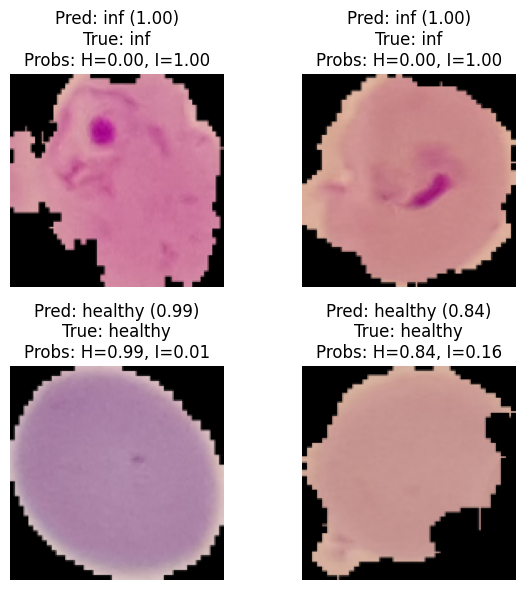

In [21]:
samples = random.sample(infected_test_fpaths, 2) + \
          random.sample(healthy_test_fpaths, 2)

plt.figure(figsize=(6,6))

for i, img_path in enumerate(samples):

    img, pred, conf, probs = predict_tflite_verbose(img_path)

    true_label = img_path.split(os.sep)[-2]

    plt.subplot(2, 2, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.title(
        f"Pred: {class_names[pred]} ({conf:.2f})\n"
        f"True: {true_label}\n"
        f"Probs: H={probs[0]:.2f}, I={probs[1]:.2f}",
        fontsize=12
    )

plt.tight_layout()
plt.show()

In [12]:
# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="malaria_model_quantized.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Reset test generator (important)
test_generator.reset()

y_true = []
y_pred = []

for i in range(len(test_generator)):

    x_batch, y_batch = test_generator[i]   # batch_size = 1 in your case

    # Convert input to float32 (VERY IMPORTANT for TFLite)
    x_batch = x_batch.astype(np.float32)

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], x_batch)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])

    pred_class = np.argmax(output, axis=1)[0]
    true_class = np.argmax(y_batch, axis=1)[0]

    y_pred.append(pred_class)
    y_true.append(true_class)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Accuracy
accuracy = np.mean(y_true == y_pred)

print(f"TFLite Quantized Model Accuracy: {accuracy:.4f}")

TFLite Quantized Model Accuracy: 0.9503


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred))

print(classification_report(
    y_true, y_pred,
    target_names=['healthy', 'infected']
))

[[1328   71]
 [  68 1331]]
              precision    recall  f1-score   support

     healthy       0.95      0.95      0.95      1399
    infected       0.95      0.95      0.95      1399

    accuracy                           0.95      2798
   macro avg       0.95      0.95      0.95      2798
weighted avg       0.95      0.95      0.95      2798

